Using Ragas for evaluation: https://docs.ragas.io/en/latest/getstarted/index.html

In [1]:
%pip install --upgrade pip

# Uninstall conflicting packages
%pip uninstall -y langchain-core langchain-openai langchain-experimental langchain-community langchain chromadb beautifulsoup4 python-dotenv PyPDF2 rank_bm25 ragas tqdm matplotlib

# Install compatible versions of langchain-core and langchain-openai
%pip install langchain-core==0.3.6
%pip install langchain-openai==0.2.1
%pip install langchain-experimental==0.3.2
%pip install langchain-community==0.3.1
%pip install langchain==0.3.1

# Install remaining packages
%pip install chromadb==0.5.11
%pip install python-dotenv==1.0.1
%pip uninstall uvloop -y
%pip install PyPDF2==3.0.1 -q --user
%pip install rank_bm25==0.2.2

# new
%pip install ragas==0.1.20
%pip install tqdm==4.66.5 -q --user
%pip install matplotlib==3.9.2

# Restart the kernel after installation

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 21.3 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
Found existing installation: langchain-core 0.3.68
Uninstalling langchain-core-0.3.68:
  Successfully uninstalled langchain-core-0.3.68
Found existing installation: langchain 0.3.26
Uninstalling langchain-0.3.26:
  Successfully uninstalled langchain-0.3.26
Found existing installation: beautifulsoup4 4.13.4
Uninstalling beautifulsoup4-4.13.4:
  Successfully uninstalled beautifulsoup4-4.13.4
Found existing installation: tqdm 4.67.1
Uninstalling tqdm-4.67.1:
  Successfully uninstalled tqdm-4.67.1
Found existing installation: matplotlib 3.10.0
Uninstalling matplotlib-3.10.0:
  Successfully uninstalled matplotlib-3.10.0
  Attempting uninstall: langsmith
    Found existing installation: langsmith 0.4.4
    Uninstalling langsmith-0.4.4:
      Successfully uninstalled langsmith

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 19.4 MB/s eta 0:00:00
  Attempting uninstall: langchain
    Found existing installation: langchain 0.3.25
    Uninstalling langchain-0.3.25:
      Successfully uninstalled langchain-0.3.25
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 604.0/604.0 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 60.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 71.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 93.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 92.7 MB/s eta 0:00:00
  Created wheel for pypika: filename=pypika-0.48.9-py2.py3-none-any.whl size=53803 sha256=eddd6634450285454f1c6a649bffa6097fed0421c7513c2363c1e7cff391d31a
  Stored in directory: /root/.cache/pip/wheels/a3/01/bd/4c40ceb9d5354160cb1

In [2]:
import os
os.environ['USER_AGENT'] = 'RAGUserAgent'
import openai
from langchain_openai import AzureChatOpenAI, AzureOpenAIEmbeddings
from langchain import hub
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
import chromadb
from langchain_community.vectorstores import Chroma
from langchain_core.runnables import RunnableParallel
from dotenv import load_dotenv, find_dotenv
from langchain_core.prompts import PromptTemplate
from PyPDF2 import PdfReader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.docstore.document import Document
from langchain_community.retrievers import BM25Retriever
from langchain.retrievers import EnsembleRetriever

## new
import tqdm as notebook_tqdm
import pandas as pd
import matplotlib.pyplot as plt
from datasets import Dataset
from ragas import evaluate
from ragas.testset.generator import TestsetGenerator
from ragas.testset.evolutions import simple, reasoning, multi_context
from ragas.metrics import (
    answer_relevancy,
    faithfulness,
    context_recall,
    context_precision,
    answer_correctness,
    answer_similarity
)

In [3]:
# OpenAI Setup
!pip install google.colab
from google.colab import userdata
os.environ["OPENAI_API_VERSION"] = "2024-08-01-preview"
os.environ['AZURE_OPENAI_API_KEY'] = userdata.get('AZURE_OPENAI_API_KEY')
os.environ["AZURE_OPENAI_ENDPOINT"] = userdata.get('AZURE_OPENAI_ENDPOINT')
os.environ["AZURE_OPENAI_EMBEDDING_ENDPOINT"] = userdata.get('AOAI_EMBEDDING_ENDPOINT')
embedding_function = AzureOpenAIEmbeddings(model="text-embedding-ada-002", azure_endpoint=userdata.get('AOAI_EMBEDDING_ENDPOINT'), api_key=userdata.get('AOAI_EMBEDDING_KEY'))
llm = AzureChatOpenAI(model_name="gpt-4o-mini")

# variables
pdf_path = "sample_data/google-2023-environmental-report.pdf"
collection_name = "google_environmental_report"
str_output_parser = StrOutputParser()
user_query = "What are Google's environmental initiatives?"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [beautifulsoup4]


In [4]:
# LLMs/Embeddings
embedding_ada = "text-embedding-ada-002"
model_gpt35="gpt-3.5-turbo"
model_gpt4="gpt-4o-mini"

llm = AzureChatOpenAI(model=model_gpt35, openai_api_key=openai.api_key, temperature=0.0)
generator_llm = AzureChatOpenAI(model=model_gpt35, openai_api_key=openai.api_key, temperature=0.0)
critic_llm = AzureChatOpenAI(model=model_gpt4, openai_api_key=openai.api_key, temperature=0.0)

In [5]:
#### INDEXING ####

In [9]:
# # Load the PDF and extract text
pdf_reader = PdfReader(pdf_path)
text = ""
for page in pdf_reader.pages:
    text += page.extract_text()

In [10]:
# Split
character_splitter = RecursiveCharacterTextSplitter(
    separators=["\n\n", "\n", ". ", " ", ""],
    chunk_size=1000,
    chunk_overlap=200
)
splits = character_splitter.split_text(text)

In [11]:
dense_documents = [Document(page_content=text, metadata={"id": str(i), "source": "dense"}) for i, text in enumerate(splits)]
sparse_documents = [Document(page_content=text, metadata={"id": str(i), "source": "sparse"}) for i, text in enumerate(splits)]

In [12]:
chroma_client = chromadb.Client()
vectorstore = Chroma.from_documents(
    documents=dense_documents,
    embedding=embedding_function,
    collection_name=collection_name,
    client=chroma_client
)

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


In [13]:
dense_retriever = vectorstore.as_retriever(search_kwargs={"k": 10})
sparse_retriever = BM25Retriever.from_documents(sparse_documents, k=10)
ensemble_retriever = EnsembleRetriever(retrievers=[dense_retriever, sparse_retriever], weights=[0.5, 0.5], c=0)

In [14]:
#### RETRIEVAL and GENERATION ####

In [15]:
# Prompt - ignore LangSmith warning, you will not need langsmith for this coding exercise
prompt = hub.pull("jclemens24/rag-prompt")

/usr/local/lib/python3.11/dist-packages/langsmith/client.py:241: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(


In [16]:
# Relevance check prompt
relevance_prompt_template = PromptTemplate.from_template(
    """
    Given the following question and retrieved context, determine if the context is relevant to the question.
    Provide a score from 1 to 5, where 1 is not at all relevant and 5 is highly relevant.
    Return ONLY the numeric score, without any additional text or explanation.

    Question: {question}
    Retrieved Context: {retrieved_context}

    Relevance Score:"""
)

In [17]:
# Post-processing
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

In [18]:
def extract_score(llm_output):
    try:
        score = float(llm_output.strip())
        return score
    except ValueError:
        return 0

# Chain it all together with LangChain
def conditional_answer(x):
    relevance_score = extract_score(x['relevance_score'])
    if relevance_score < 4:
        return "I don't know."
    else:
        return x['answer']

In [19]:
rag_chain_from_docs = (
    RunnablePassthrough.assign(context=(lambda x: format_docs(x["context"])))
    | RunnableParallel(
        {"relevance_score": (
            RunnablePassthrough()
            | (lambda x: relevance_prompt_template.format(question=x['question'], retrieved_context=x['context']))
            | llm
            | str_output_parser
        ), "answer": (
            RunnablePassthrough()
            | prompt
            | llm
            | str_output_parser
        )}
    )
    | RunnablePassthrough().assign(final_answer=conditional_answer)
)

In [20]:
rag_chain_similarity = RunnableParallel(
    {"context": dense_retriever,
     "question": RunnablePassthrough()
}).assign(answer=rag_chain_from_docs)

In [21]:
rag_chain_hybrid = RunnableParallel(
    {"context": ensemble_retriever,
     "question": RunnablePassthrough()
}).assign(answer=rag_chain_from_docs)

In [22]:
# Question - Submitted to the similarity / dense vector search
result = rag_chain_similarity.invoke(user_query)
retrieved_docs = result['context']

print(f"Original Question to Similarity Search: {user_query}\n")
print(f"Relevance Score: {result['answer']['relevance_score']}\n")
print(f"Final Answer:\n{result['answer']['final_answer']}\n\n")
print("Retrieved Documents:")
for i, doc in enumerate(retrieved_docs, start=1):
    print(f"Document {i}: Document ID: {doc.metadata['id']} source: {doc.metadata['source']}")
    print(f"Content:\n{doc.page_content}\n")

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given


Original Question to Similarity Search: What are Google's environmental initiatives?

Relevance Score: 5

Final Answer:
Google's environmental initiatives include empowering individuals to take action, working together with partners and customers, operating sustainably, achieving net-zero carbon emissions, focusing on water stewardship, and promoting a circular economy. They have set goals to help individuals and partners reduce carbon emissions and have implemented sustainability features in their products like eco-friendly routing in Google Maps and energy efficiency features in Google Nest thermostats. Google is also involved in various partnerships and initiatives to address climate change and ecosystem degradation, such as the iMasons Climate Accord, ReFED, and supporting projects with The Nature Conservancy. Additionally, Google is a member of organizations like the World Business Council for Sustainable Development and the World Resources Institute to collaborate on sustainabili

In [23]:
# Question - Submitted to the hybrid / multi-vector search
result = rag_chain_hybrid.invoke(user_query)
retrieved_docs = result['context']

print(f"Original Question to Dense Search: {user_query}\n")
print(f"Relevance Score: {result['answer']['relevance_score']}\n")
print(f"Final Answer:\n{result['answer']['final_answer']}\n\n")
print("Retrieved Documents:")
for i, doc in enumerate(retrieved_docs, start=1):
    print(f"Document {i}: Document ID: {doc.metadata['id']} source: {doc.metadata['source']}")
    print(f"Content:\n{doc.page_content}\n")

Original Question to Dense Search: What are Google's environmental initiatives?

Relevance Score: 5

Final Answer:
Google's environmental initiatives include empowering individuals to take action, working together with partners and customers, operating sustainably, achieving net-zero carbon emissions, focusing on water stewardship, engaging in a circular economy, and supporting sustainable consumption of public goods. Google also engages with suppliers to reduce energy consumption and greenhouse gas emissions, reports environmental data, and audits suppliers for compliance with environmental criteria. Additionally, Google is involved in various sustainability initiatives and partnerships, such as the iMasons Climate Accord, ReFED, and The Nature Conservancy. Google also invests in breakthrough innovation, renewable energy, and sustainability-focused accelerators to drive climate action and sustainability.


Retrieved Documents:
Document 1: Document ID: 451 source: dense
Content:
Empowe

#### SIMILARITY SEARCH ONLY
Google's environmental initiatives include empowering individuals to take action, working together with partners and customers, operating sustainably, achieving net-zero carbon emissions, water stewardship, and promoting a circular economy. They have implemented sustainability features in products like Google Maps, Google Nest thermostats, and Google Flights to help individuals make more sustainable choices. Google also supports various environmental organizations and initiatives, such as the iMasons Climate Accord, ReFED, and The Nature Conservancy, to accelerate climate action and address environmental challenges. Additionally, Google is involved in public policy advocacy and is committed to reducing its environmental impact through its operations and value chain.


#### HYBRID SEARCH

Google's environmental initiatives include empowering individuals to take action, working together with partners and customers, operating sustainably, achieving net-zero carbon emissions, focusing on water stewardship, promoting a circular economy, engaging with suppliers to reduce energy consumption and greenhouse gas emissions, and reporting environmental data. They also support public policy and advocacy for low-carbon economies, participate in initiatives like the iMasons Climate Accord and ReFED, and support projects with organizations like The Nature Conservancy. Additionally, Google is involved in initiatives with the World Business Council for Sustainable Development and the World Resources Institute to improve well-being for people and the planet. They are also working on using technology and platforms to organize information about the planet and make it actionable to help partners and customers create a positive impact.

### SYNTHETIC DATA GENERATION

In [24]:
# generator with openai models
generator = TestsetGenerator.from_langchain(
    generator_llm,
    critic_llm,
    embedding_function
)

In [26]:
# Create a list of Document objects from the chunks
documents = [Document(page_content=chunk) for chunk in splits]

#### FOR FOLLOWING CODE: Uncomment and run once to generate source for test dataset! ####
# generate testset -
testset = generator.generate_with_langchain_docs(
    documents,
    test_size=10,
    distributions={
        simple: 0.5,
        reasoning: 0.25,
        multi_context: 0.25
    }
)

embedding nodes:   0%|          | 0/906 [00:00<?, ?it/s]

Generating:   0%|          | 0/10 [00:00<?, ?it/s]

In [27]:
# comparison dataframe
testset_df = testset.to_pandas()

# save dataframes to CSV files in the specified directory
testset_df.to_csv(os.path.join('testset_data.csv'), index=False)

print("testset DataFrame saved successfully in the local directory.")

testset DataFrame saved successfully in the local directory.


In [28]:
# pull data from saved testset, rather than generating above
### load dataframs from CSV file
saved_testset_df = pd.read_csv(os.path.join('testset_data.csv'))
print("testset DataFrame loaded successfully from local directory.")
saved_testset_df.head(5)

testset DataFrame loaded successfully from local directory.


,question,contexts,ground_truth,evolution_type,metadata,episode_done
0,How are carbon emissions estimates displayed o...,"['When individuals search in Google Flights, t...",Carbon emissions estimates are displayed on Go...,simple,[{}],True
1,What factors are considered when determining m...,['Data \nmeasurement and\xa0uncertainty\nAll r...,We base our estimates and methodologies on his...,simple,[{}],True
2,How has Google supported strong climate polici...,['We’ve consistently supported strong climate ...,Google has consistently supported strong clima...,simple,[{}],True
3,How is Google supporting the reforestation of ...,['iMasons Climate AccordGoogle is a founding m...,Google supported the reforestation of kelp thr...,simple,[{}],True
4,How are consumer choices linked to achieving a...,['that Google can make a meaningful difference...,Consumer choices are linked to achieving a net...,simple,[{}],True


### PREPARE SIMILARITY SEARCH DATASET

In [29]:
# Convert the DataFrame to a dictionary
saved_testing_data = saved_testset_df.astype(str).to_dict(orient='list')

# Create the testing_dataset
saved_testing_dataset = Dataset.from_dict(saved_testing_data)

# Update the testing_dataset to include only these columns -
# "question", "ground_truth", "answer", "contexts"
saved_testing_dataset_sm = saved_testing_dataset.remove_columns(["evolution_type", "episode_done"])

In [30]:
saved_testing_dataset_sm

Dataset({
    features: ['question', 'contexts', 'ground_truth', 'metadata'],
    num_rows: 10
})

### EVAL SETS FOR EACH CHAIN

In [31]:
# Function to generate answers using the RAG chain
def generate_answer(question, ground_truth, rag_chain):
    result = rag_chain.invoke(question)
    return {
        "question": question,
        "answer": result["answer"]["final_answer"],
        "contexts": [doc.page_content for doc in result["context"]],
        "ground_truth": ground_truth
    }

In [32]:
# Add the "question", "answer", "contexts", and "ground_truth" to the testing_dataset
testing_dataset_similarity = saved_testing_dataset_sm.map(lambda x: generate_answer(x["question"], x["ground_truth"], rag_chain_similarity), remove_columns=saved_testing_dataset_sm.column_names)

Parameter 'function'=<function <lambda> at 0x7af07950eac0> of the transform datasets.arrow_dataset.Dataset._map_single couldn't be hashed properly, a random hash was used instead. Make sure your transforms and parameters are serializable with pickle or dill for the dataset fingerprinting and caching to work. If you reuse this transform, the caching mechanism will consider it to be different from the previous calls and recompute everything. This warning is only showed once. Subsequent hashing failures won't be showed.


Map:   0%|          | 0/10 [00:00<?, ? examples/s]

In [33]:
# Add the "question", "answer", "contexts", and "ground_truth" to the testing_dataset
testing_dataset_hybrid = saved_testing_dataset_sm.map(lambda x: generate_answer(x["question"], x["ground_truth"], rag_chain_hybrid), remove_columns=saved_testing_dataset_sm.column_names)

Map:   0%|          | 0/10 [00:00<?, ? examples/s]

### EVAL SCORING

In [43]:
# Similarity search score
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper

llm_wrapper = LangchainLLMWrapper(llm)
embedding_wrapper = LangchainEmbeddingsWrapper(embedding_function)

score_similarity = evaluate(
    testing_dataset_similarity,
    llm=llm_wrapper,
    embeddings=embedding_wrapper,
    metrics=[
        faithfulness,
        answer_relevancy,
        context_precision,
        context_recall,
        answer_correctness,
        answer_similarity
    ]
)
similarity_df = score_similarity.to_pandas()
similarity_df

Evaluating:   0%|          | 0/60 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/datasets/table.py:1395: FutureWarning: promote has been superseded by promote_options='default'.
  block_group = [InMemoryTable(cls._concat_blocks(list(block_group), axis=axis))]
/usr/local/lib/python3.11/dist-packages/datasets/table.py:1421: FutureWarning: promote has been superseded by promote_options='default'.
  table = cls._concat_blocks(blocks, axis=0)


,question,contexts,answer,ground_truth,faithfulness,answer_relevancy,context_precision,context_recall,answer_correctness,answer_similarity
0,How are carbon emissions estimates displayed o...,"[When individuals search in Google Flights, th...",Carbon emissions estimates are displayed on Go...,Carbon emissions estimates are displayed on Go...,1.000000,0.898151,0.906041,1.00,0.594485,0.993326
1,What factors are considered when determining m...,[All environmental data found in this report i...,Factors considered when determining methodolog...,We base our estimates and methodologies on his...,1.000000,0.999999,0.827438,0.25,0.423002,0.834865
2,How has Google supported strong climate polici...,[We’ve consistently supported strong climate p...,Google has supported strong climate policies a...,Google has consistently supported strong clima...,1.000000,0.945254,0.976543,1.00,0.800348,0.951393
3,How is Google supporting the reforestation of ...,[iMasons Climate AccordGoogle is a founding me...,Google is supporting the reforestation of kelp...,Google supported the reforestation of kelp thr...,1.000000,0.933697,0.902857,1.00,0.461050,0.987058
4,How are consumer choices linked to achieving a...,[that Google can make a meaningful difference ...,Consumer choices are linked to achieving a net...,Consumer choices are linked to achieving a net...,1.000000,0.983261,0.988889,1.00,0.670437,0.967462
5,How does Green Light help city traffic enginee...,[Road traffic\nWe also know that many cities s...,Green Light helps city traffic engineers optim...,Green Light is an AI-based tool that helps cit...,1.000000,0.979921,0.866667,1.00,0.745012,0.980049
6,How did Google.org support nonprofit projects ...,"[• AI for the Global Goals , $25 million in fu...","In 2022, Google.org supported nonprofit projec...",Google.org supported nonprofit projects in the...,0.750000,0.968584,0.976190,1.00,0.790700,0.980982
7,What data is in the global water tables in the...,"[In 2022, we described our climate-conscious d...",The global water tables in the company's repor...,The global water tables in the company's repor...,1.000000,0.933275,0.864435,1.00,0.740935,0.963742
8,What impact do renewable energy purchases have...,[0246\n2.49Scope 2 emissions \n(million tCO2e)...,Renewable energy purchases have a significant ...,Renewable energy purchases have a significant ...,1.000000,0.969674,1.000000,1.00,0.772418,0.989671
9,How does Google prioritize replenishment proje...,[In addition to focusing on responsible water ...,Google prioritizes replenishment projects in w...,Google prioritizes replenishment projects in w...,0.857143,0.937435,1.000000,1.00,0.877611,0.984126


In [44]:
# similarity search score
score_hybrid = evaluate(
    testing_dataset_hybrid,
    llm=llm_wrapper,
    embeddings=embedding_wrapper,
    metrics=[
        faithfulness,
        answer_relevancy,
        context_precision,
        context_recall,
        answer_correctness,
        answer_similarity
    ]
)
hybrid_df = score_hybrid.to_pandas()
hybrid_df

Evaluating:   0%|          | 0/60 [00:00<?, ?it/s]

ERROR:ragas.executor:Exception raised in Job[38]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[44]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[14]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[26]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[20]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[50]: TimeoutError()
/usr/local/lib/python3.11/dist-packages/datasets/table.py:1395: FutureWarning: promote has been superseded by promote_options='default'.
  block_group = [InMemoryTable(cls._concat_blocks(list(block_group), axis=axis))]
/usr/local/lib/python3.11/dist-packages/datasets/table.py:1421: FutureWarning: promote has been superseded by promote_options='default'.
  table = cls._concat_blocks(blocks, axis=0)


,question,contexts,answer,ground_truth,faithfulness,answer_relevancy,context_precision,context_recall,answer_correctness,answer_similarity
0,How are carbon emissions estimates displayed o...,"[When individuals search in Google Flights, th...",Carbon emissions estimates on Google Flights a...,Carbon emissions estimates are displayed on Go...,1.000000,0.896450,0.889435,1.0,0.772061,0.988242
1,What factors are considered when determining m...,[All environmental data found in this report i...,When determining methodologies for data measur...,We base our estimates and methodologies on his...,1.000000,0.999999,0.695700,1.0,0.206018,0.824074
2,How has Google supported strong climate polici...,[We’ve consistently supported strong climate p...,Google has supported strong climate policies a...,Google has consistently supported strong clima...,1.000000,0.966086,NaN,1.0,0.764345,0.957379
3,How is Google supporting the reforestation of ...,[iMasons Climate AccordGoogle is a founding me...,Google is supporting the reforestation of kelp...,Google supported the reforestation of kelp thr...,1.000000,0.933697,NaN,1.0,0.461050,0.987058
4,How are consumer choices linked to achieving a...,[that Google can make a meaningful difference ...,Consumer choices are linked to achieving a net...,Consumer choices are linked to achieving a net...,1.000000,0.983261,NaN,1.0,0.546078,0.984313
5,How does Green Light help city traffic enginee...,[Road traffic\nWe also know that many cities s...,Green Light helps city traffic engineers optim...,Green Light is an AI-based tool that helps cit...,0.500000,0.979921,0.670996,1.0,0.790565,0.980440
6,How did Google.org support nonprofit projects ...,"[• AI for the Global Goals , $25 million in fu...","In 2022, Google.org supported nonprofit projec...",Google.org supported nonprofit projects in the...,0.750000,0.899889,NaN,1.0,0.790700,0.980982
7,What data is in the global water tables in the...,"[In 2022, we described our climate-conscious d...",The global water tables in the company's repor...,The global water tables in the company's repor...,0.857143,0.937859,NaN,1.0,0.641329,0.965317
8,What impact do renewable energy purchases have...,[0246\n2.49Scope 2 emissions \n(million tCO2e)...,Renewable energy purchases have a significant ...,Renewable energy purchases have a significant ...,1.000000,0.999999,NaN,1.0,0.496106,0.984426
9,How does Google prioritize replenishment proje...,[In addition to focusing on responsible water ...,Google prioritizes replenishment projects in w...,Google prioritizes replenishment projects in w...,0.400000,0.937473,0.838994,1.0,0.745875,0.983501


### ANALYSIS

In [45]:
# Analysis that consolidates everything into easier-to-read scores
# key columns to compare
key_columns = [
    'faithfulness',
    'answer_relevancy',
    'context_precision',
    'context_recall',
    'answer_correctness',
    'answer_similarity'
]

# mean scores for each key column in similarity_df
similarity_means = similarity_df[key_columns].mean()

# mean scores for each key column in hybrid_df
hybrid_means = hybrid_df[key_columns].mean()

# comparison dataframe
comparison_df = pd.DataFrame({'Similarity Run': similarity_means, 'Hybrid Run': hybrid_means})

# difference between the means
comparison_df['Difference'] = comparison_df['Similarity Run'] - comparison_df['Hybrid Run']

# save dataframes to CSV files in the specified directory
similarity_df.to_csv(os.path.join('similarity_run_data.csv'), index=False)
hybrid_df.to_csv(os.path.join('hybrid_run_data.csv'), index=False)
comparison_df.to_csv(os.path.join('comparison_data.csv'), index=True)

print("Dataframes saved successfully in the local directory.")

Dataframes saved successfully in the local directory.


In [46]:
### load dataframes from CSV files
sem_df = pd.read_csv(os.path.join('similarity_run_data.csv'))
rec_df = pd.read_csv(os.path.join('hybrid_run_data.csv'))
comparison_df = pd.read_csv(os.path.join('comparison_data.csv'), index_col=0)

print("Dataframes loaded successfully from the local directory.")

# Analysis that consolidates everything into easier to read scores
print("Performance Comparison:")
print("\n**Retrieval**:")
print(comparison_df.loc[['context_precision', 'context_recall']])
print("\n**Generation**:")
print(comparison_df.loc[['faithfulness', 'answer_relevancy']])
print("\n**End-to-end evaluation**:")
print(comparison_df.loc[['answer_correctness', 'answer_similarity']])

Dataframes loaded successfully from the local directory.
Performance Comparison:

**Retrieval**:
                   Similarity Run  Hybrid Run  Difference
context_precision        0.930906    0.773781    0.157125
context_recall           0.925000    1.000000   -0.075000

**Generation**:
                  Similarity Run  Hybrid Run  Difference
faithfulness            0.960714    0.850714    0.110000
answer_relevancy        0.954925    0.953463    0.001462

**End-to-end evaluation**:
                    Similarity Run  Hybrid Run  Difference
answer_correctness        0.687600    0.621413    0.066187
answer_similarity         0.963267    0.963573   -0.000306


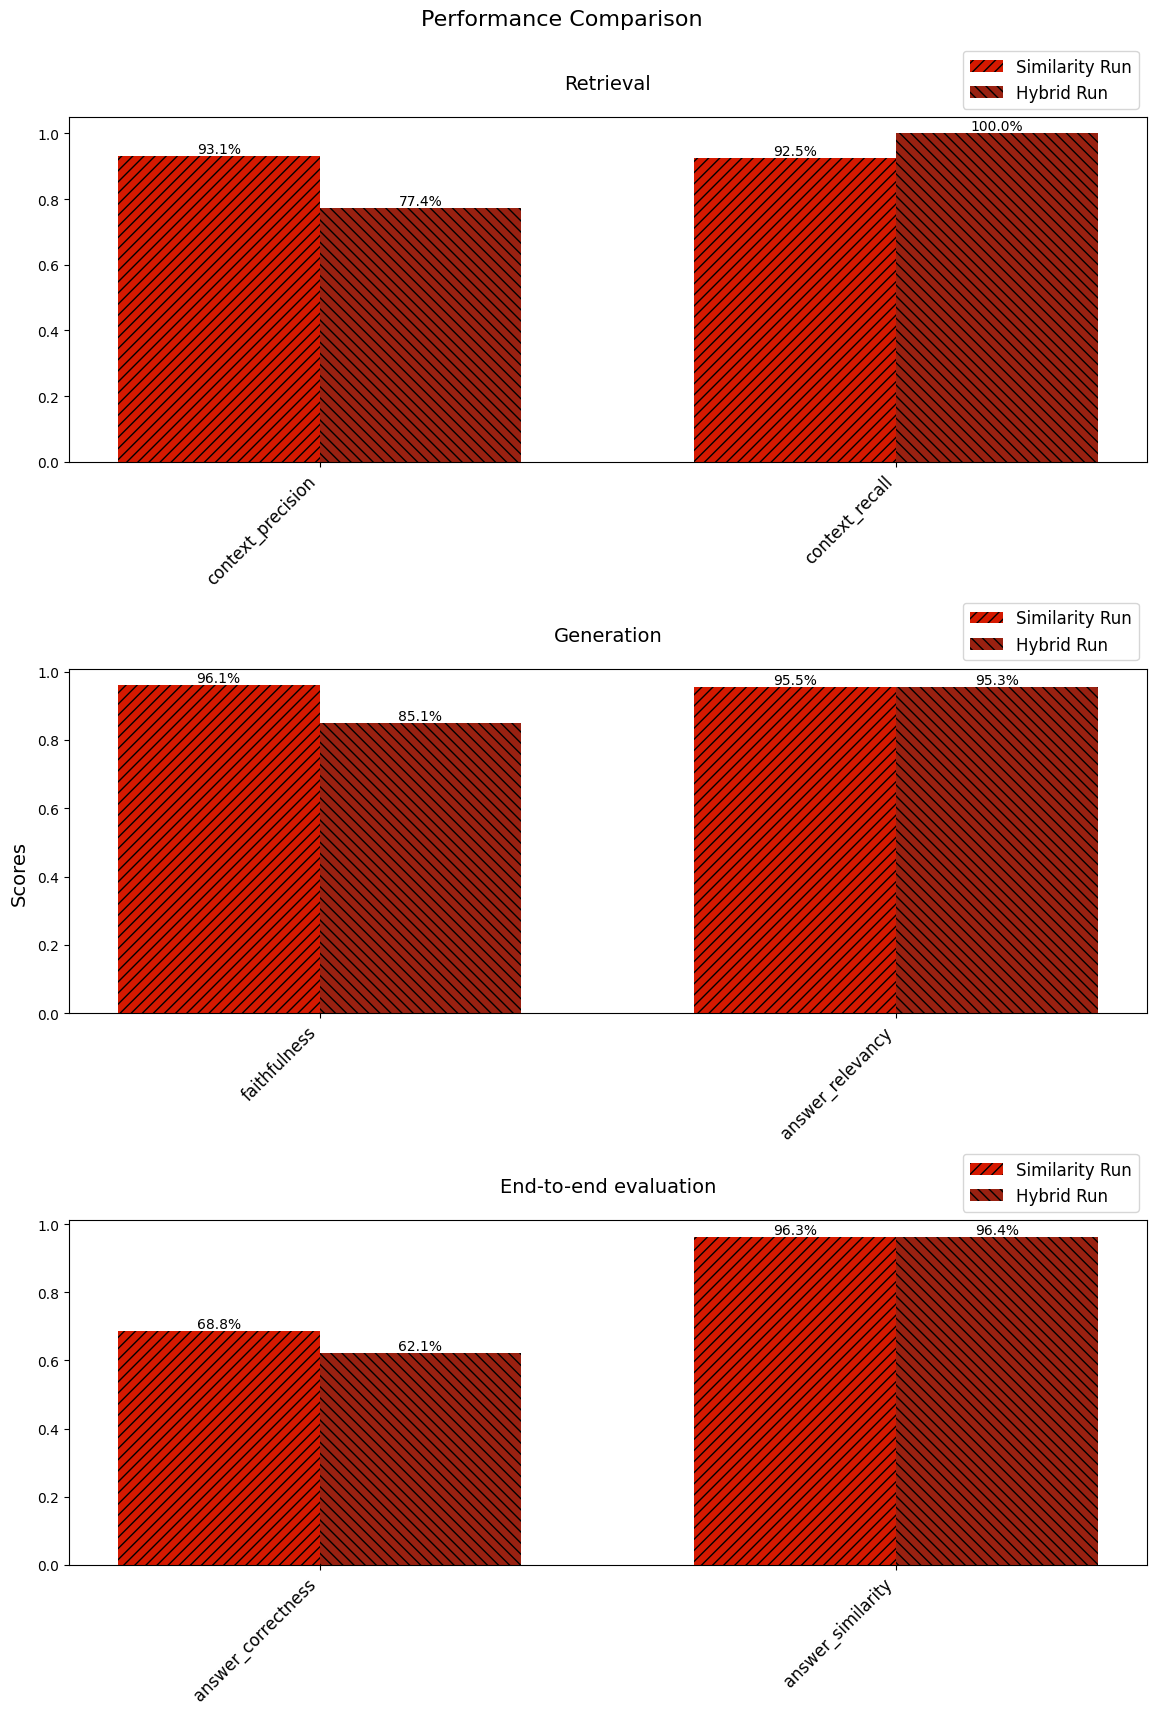

In [47]:
# plotting - create subplots for each category with increased spacing
fig, axes = plt.subplots(3, 1, figsize=(12, 18), sharex=False)
bar_width = 0.35
categories = ['Retrieval', 'Generation', 'End-to-end evaluation']
metrics = [
    ['context_precision', 'context_recall'],
    ['faithfulness', 'answer_relevancy'],
    ['answer_correctness', 'answer_similarity']
]

# iterate over each category and plot the corresponding metrics
for i, (category, metric_list) in enumerate(zip(categories, metrics)):
    ax = axes[i]
    x = range(len(metric_list))

    # plot bars for Similarity Run (hex color #D51900)
    similarity_bars = ax.bar(x, comparison_df.loc[metric_list, 'Similarity Run'], width=bar_width, label='Similarity Run', color='#D51900', hatch='///')

    # add values to Similarity Run bars
    for bar in similarity_bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.1%}', ha='center', va='bottom', fontsize=10)

    # plot bars for Hybrid Run (hex color #992111)
    hybrid_bars = ax.bar([i + bar_width for i in x], comparison_df.loc[metric_list, 'Hybrid Run'], width=bar_width, label='Hybrid Run', color='#992111', hatch='\\\\\\')

    # add values to Hybrid Run bars
    for bar in hybrid_bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.1%}', ha='center', va='bottom', fontsize=10)

    ax.set_title(category, fontsize=14, pad=20)
    ax.set_xticks([i + bar_width / 2 for i in x])
    ax.set_xticklabels(metric_list, rotation=45, ha='right', fontsize=12)

    # move the legend to the bottom right corner
    ax.legend(fontsize=12, loc='lower right', bbox_to_anchor=(1, 1))

# Add overall labels and title
fig.text(0.04, 0.5, 'Scores', va='center', rotation='vertical', fontsize=14)
fig.suptitle('Performance Comparison', fontsize=16)

# adjust the spacing between subplots and increase the top margin
plt.tight_layout(rect=[0.05, 0.03, 1, 0.95])
plt.subplots_adjust(hspace=0.6, top=0.92)
plt.show()